In [1]:
# quantum_well_2D_circle_with_Gaussian_inside
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
a = 0.5 * 10**(-9)
a_nm = a * 10**9
N = 40
L = (N+1)*a
L_nm = L*10**9
print("L=",L,"m")
print("L=",L/10**(-9),"nm")

L= 2.05e-08 m
L= 20.5 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [4]:
t = (h_bar**2) / (2*m_el*a**2)
t = t / eV_unit
print("t=",t)

t= 0.15239927954599816


In [5]:
sys = kwant.Builder()

In [6]:
lat = kwant.lattice.square(a_nm)

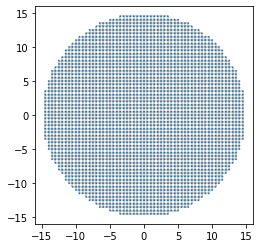

In [7]:
R = 15

sigma = 3
U = 0.5*t
def onsite(site):
    (x,y) = site.pos
    return 4*t - U*np.exp(-0.5*(x**2+y**2)/sigma**2 ) 

def circle_shape(pos):
    (x,y) = pos
    if x**2 + y**2 < R**2:
        return True
    else:
        return False
    

sys[lat.shape(circle_shape, (0,0))] = onsite
sys[lat.neighbors()] = -t

kwant.plot(sys);

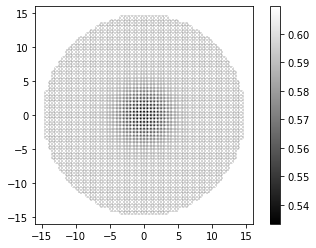

In [8]:
sysf = sys.finalized()
kwant.plot(sysf, site_color=lambda site: sysf.hamiltonian(site, site));

In [9]:
Hmat = sysf.hamiltonian_submatrix()

In [10]:
ene, v = np.linalg.eigh(Hmat)

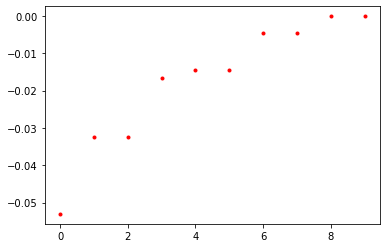

In [11]:
plt.plot(ene[:10], "r.");

In [12]:
from ipywidgets import interact

In [13]:
def plot_wf(n=0):
    kwant.plotter.map(sysf, abs(v[:,n])**2);

In [14]:
interact(plot_wf, n=(0,20))

interactive(children=(IntSlider(value=0, description='n', max=20), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_wf(n=0)>